<a href="https://colab.research.google.com/github/ankurs190/Agentic-2.0/blob/main/customer_churn_analysis_elevator_mfg_new.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Predict which customers are likely to cancel elevator maintenance contracts and identify key reasons for churn.**

**Step 1: Business Understanding**
- **Problem**: Some clients stop renewing their elevator service contracts.
- Impact: Lost revenue, higher acquisition costs, poor utilization of service technicians.
- **Goal**: Build an ML model to predict churn before it happens, so sales teams can proactively retain clients.

**Step 2: Dummy Dataset Design**- Columns you can include:

| Column                 | Description                                            |
| ---------------------- | ------------------------------------------------------ |
| Customer\_ID           | Unique customer identifier (customer demographic info)                            |
| Contract\_Length       | 12 months, 24 months, 36 months                        |
| Contract\_Age          | How many months the customer has been with the company |
| Service\_Calls         | Number of breakdown service requests in last 12 months |
| Avg\_Response\_Time    | Average technician response time (in hours)            |
| Elevator\_Age          | Age of installed elevator system (years)               |
| original Installer & manufacturer         | Age of installed elevator                |
| Number\_of\_Elevators  | Elevators under contract                               |
| Maintenance\_Cost      | Annual maintenance cost billed                         |
| Customer\_Satisfaction | Survey score (1–5)                                     |
| Payment\_Delays        | Number of delayed invoice payments                     |
| Region                 | Customer’s location (North, South, East, West)         |
| Churn                  | Target (1 = churned, 0 = retained)                     |

**🔹 Step 3: Data Preprocessing**
- Handle missing values.
- Encode categorical variables (Region).
- Normalize/scale features like cost, response time.
- Train-test split (e.g., 80%-20%).

**Step 4: Modeling** : Models to try:
- Logistic Regression (baseline)
- Random Forest / LightGBM (better performance + feature importance)
- XGBoost (if you want a powerful tree-based model)

👉 Evaluate with metrics:
- Accuracy (overall performance)
- Precision & Recall (important for churn — false negatives are costly!)
- ROC-AUC (ability to separate churn vs non-churn).

**Step 5: Explainability (Why Customers Churn):**
- Use SHAP values or feature importance to explain results.
- Possible insights: High churn risk if:
  - Contract is near end + high service calls.
  - Customer satisfaction < 3.
  - Payment delays > 2.
  - Old elevators (>15 years).

**Step 6: Deployment / Presentation**:
- Build a dashboard (Streamlit, Power BI, or Tableau) showing:
- Customer churn probability.
- Top churn reasons per customer.
- Overall churn trends.

**Step 7: Portfolio Deliverables**
- Jupyter Notebook / Python script → end-to-end ML pipeline.
- Dummy dataset (CSV) → synthetic but realistic.
- Visualization → churn probability distribution, feature importance.
- Dashboard (optional) → Streamlit app: “Churn Risk Predictor.”-

# Customer Churn Prediction – Vantage Elevation (Dummy Project)
This notebook loads the provided Excel dataset, trains a Random Forest model, evaluates it, and shows feature importances.


In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score
import matplotlib.pyplot as plt


In [ ]:
# Load dataset (make sure the Excel file is in the same folder as this notebook)
df = pd.read_excel('customer_churn_dataset.xlsx')
df.head()


,Customer_ID,Contract_Length,Contract_Age,Service_Calls,Avg_Response_Time,Elevator_Age,Number_of_Elevators,Maintenance_Cost,Customer_Satisfaction,Payment_Delays,Region,Churn
0,CUST_0001,12,12,2,0.8,14,10,5897,4,0,South,0
1,CUST_0002,36,16,0,7.0,22,14,22094,5,0,South,1
2,CUST_0003,24,24,2,5.2,10,12,41463,1,1,East,0
3,CUST_0004,24,19,2,3.4,3,15,40454,4,1,North,0
4,CUST_0005,12,8,1,6.3,9,10,28572,2,0,West,0


In [ ]:
# Encode categorical columns
le = LabelEncoder()
df['Region'] = le.fit_transform(df['Region'])

# Features and target
X = df.drop(columns=['Customer_ID', 'Churn'])
y = df['Churn']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Scale numerical features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [ ]:
# Train model
rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(X_train_scaled, y_train)

# Predictions & probabilities
y_pred = rf.predict(X_test_scaled)
y_prob = rf.predict_proba(X_test_scaled)[:, 1]

# Evaluation
print('Classification Report:')
print(classification_report(y_test, y_pred))
print('ROC-AUC Score:', roc_auc_score(y_test, y_prob))


Classification Report:
              precision    recall  f1-score   support

           0       0.61      0.68      0.64       111
           1       0.54      0.47      0.50        89

    accuracy                           0.58       200
   macro avg       0.58      0.57      0.57       200
weighted avg       0.58      0.58      0.58       200

ROC-AUC Score: 0.613726085636198


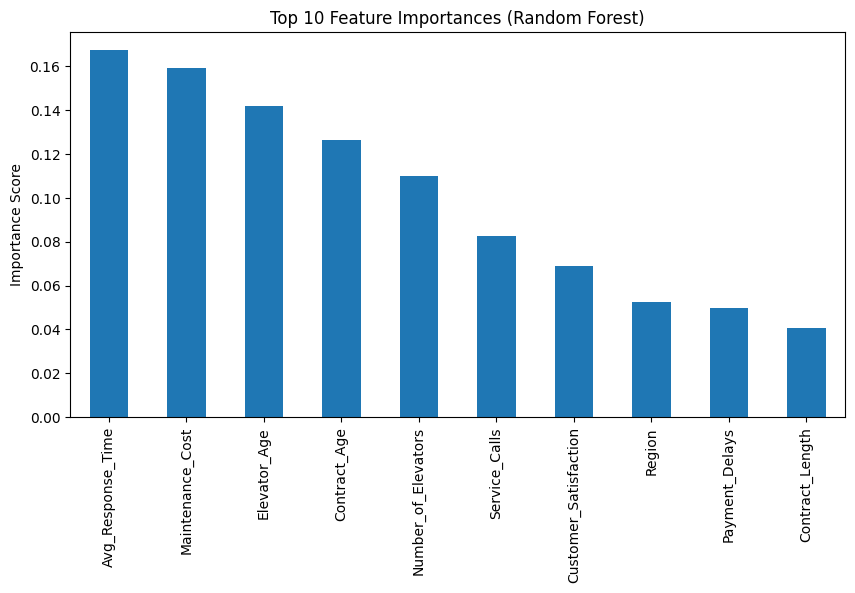

In [ ]:
# Feature importances plot
importances = rf.feature_importances_
feat_importances = pd.Series(importances, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(10, 5))
feat_importances.head(10).plot(kind='bar')
plt.title('Top 10 Feature Importances (Random Forest)')
plt.ylabel('Importance Score')
plt.show()


Customer Satisfaction & Complaint Analysis

Use NLP on customer emails, calls, and complaint notes to classify sentiment and root causes.

Cluster recurring product issues (e.g., faulty screens, defective boards).

Dashboard integration for real-time sentiment & complaint tracking.